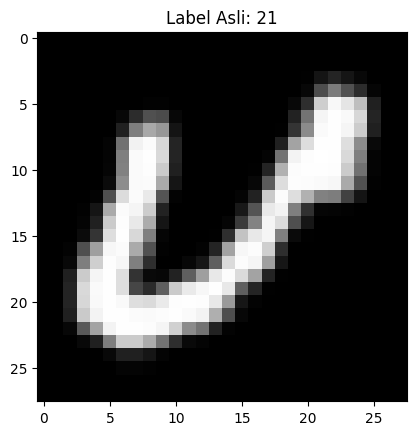

Mengekstraksi fitur HOG, mohon tunggu...
Memulai proses Grid Search SVM (Bisa memakan waktu 5-10 menit)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Parameter SVM Terbaik: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        20
           2       0.95      0.90      0.92        20
           3       0.77      0.85      0.81        20
           4       0.89      0.85      0.87        20
           5       0.89      0.85      0.87        20
           6       0.89      0.85      0.87        20
           7       0.78      0.70      0.74        20
           8       0.90      0.90      0.90        20
           9       0.65      0.55      0.59        20
          10       1.00      0.95      0.97        20
          11       0.90      0.90      0.90        20
          12       0.59      0.65      0.62        20
          13       0.95      0.95   

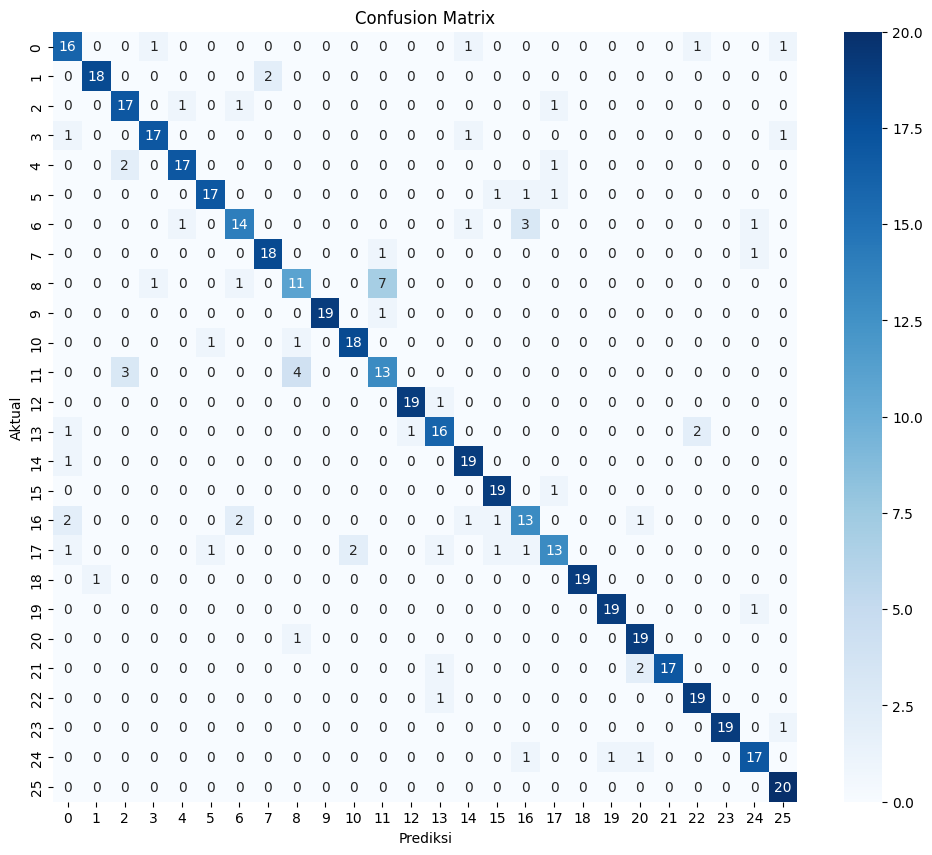

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from skimage.feature import hog
from sklearn.utils import shuffle

# 1. PERSIAPAN DATASET
# Pastikan nama file CSV sudah sesuai dengan yang ada di foldermu
data_path = 'emnist-letters-train.csv' 
dataset = pd.read_csv(data_path)

# Mengambil X (pixel) dan y (label/kelas)
y_full = dataset.iloc[:, 0].values
X_full = dataset.iloc[:, 1:].values

# Mengambil 100 sampel untuk masing-masing 26 kelas (total 2600 sampel agar seimbang)
X_balanced = []
y_balanced = []

for i in range(1, 27): 
    idx = np.where(y_full == i)[0]
    idx_sampled = idx[:100]
    
    X_balanced.extend(X_full[idx_sampled])
    y_balanced.extend(y_full[idx_sampled])

X_balanced = np.array(X_balanced)
y_balanced = np.array(y_balanced)

# Shuffle dataset dengan random_state baru 
X_shuffled, y_shuffled = shuffle(X_balanced, y_balanced, random_state=123)

# Visualisasi satu contoh gambar (Menampilkan data ke-25, bukan data ke-0)
sample_index = 25
sample_img = X_shuffled[sample_index].reshape(28, 28).T 
plt.imshow(sample_img, cmap='gray')
plt.title(f"Label Asli: {y_shuffled[sample_index]}")
plt.show()


# 2. EKSTRAKSI FITUR (HOG)
def extract_hog_features(images):
    hog_features = []
    for img in images:
        # Reshape menjadi citra 2D (28x28) lalu di-transpose
        img_2d = img.reshape(28, 28).T
        
        # Tuning parameter 
        fd = hog(img_2d, 
                 orientations=8, 
                 pixels_per_cell=(4, 4), 
                 cells_per_block=(2, 2), 
                 visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

print("Mengekstraksi fitur HOG, mohon tunggu...")
X_features = extract_hog_features(X_shuffled)


# 3. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_shuffled, test_size=0.20, stratify=y_shuffled, random_state=123
)


# 4. KLASIFIKASI DENGAN SVM & GRID SEARCH
param_grid = {
    'C': [1, 10, 50], 
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

print("Memulai proses Grid Search SVM (Bisa memakan waktu 5-10 menit)...")
svm_model = SVC()
grid = GridSearchCV(svm_model, param_grid, cv=5, verbose=2, n_jobs=-1) 
grid.fit(X_train, y_train)

print(f"\nParameter SVM Terbaik: {grid.best_params_}")


# 5. EVALUASI PERFORMA
y_pred = grid.predict(X_test)

# Menampilkan hasil evaluasi (Accuracy, Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [6]:
pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.9 MB 6.7 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/11.9 MB 8.4 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.9 MB 6.6 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/11.9 MB 6.3 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/11.9 MB 7.0 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/11.9 MB 7.8 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/11.9 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 8.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 10.5 MB/s  0:00:00

   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tiff